## FMCG Sector Financial Ratio Analysis (2021-2026)
- Comparative financial health analysis of 7 major NSE-listed FMCG companies (Hindustan Unilever, ITC, Nestle India, Britannia, Dabur, Godrej Consumer, Marico) using Python and yfinance. Analyzes profitability (ROE), liquidity (Current Ratio), and leverage (Debt-to-Equity) trends to identify each company's financial strategy and risk profile.

### Importing libraries

In [1]:
import yfinance as yf
import pandas as pd
import time
import os
import matplotlib.pyplot as plt
import seaborn as sns

### Data Collection (Latest Year)

In [3]:
# ---- FMCG Companies (NSE tickers) ----
companies = {
    "Hindustan Unilever": "HINDUNILVR.NS",
    "ITC": "ITC.NS",
    "Nestle India": "NESTLEIND.NS",
    "Britannia": "BRITANNIA.NS",
    "Dabur": "DABUR.NS",
    "Godrej Consumer": "GODREJCP.NS",
    "Marico": "MARICO.NS",
}

output_folder = "fmcg_data"
os.makedirs(output_folder, exist_ok=True)

def get_value(df, possible_labels):
    for label in possible_labels:
        if label in df.index:
            row = df.loc[label]
            for val in row:
                if pd.notna(val):
                    return val
    return None

results = []

for name, ticker in companies.items():
    print(f"Fetching {name} ({ticker})...")
    stock = yf.Ticker(ticker)

    try:
        balance_sheet = stock.balance_sheet
        income_stmt = stock.income_stmt

        safe_name = name.replace(" ", "_")
        balance_sheet.to_csv(f"{output_folder}/{safe_name}_balance_sheet.csv")
        income_stmt.to_csv(f"{output_folder}/{safe_name}_income_statement.csv")

        net_income = get_value(income_stmt, ["Net Income", "Net Income Common Stockholders"])
        total_equity = get_value(balance_sheet, ["Stockholders Equity", "Total Equity Gross Minority Interest"])
        current_assets = get_value(balance_sheet, ["Current Assets"])
        current_liabilities = get_value(balance_sheet, ["Current Liabilities"])
        total_debt = get_value(balance_sheet, ["Total Debt"])

        roe = (net_income / total_equity * 100) if net_income and total_equity else None
        current_ratio = (current_assets / current_liabilities) if current_assets and current_liabilities else None
        debt_to_equity = (total_debt / total_equity) if total_debt and total_equity else None

        results.append({
            "Company": name,
            "Net Income (Cr)": round(net_income / 1e7, 2) if net_income else None,
            "Total Equity (Cr)": round(total_equity / 1e7, 2) if total_equity else None,
            "ROE (%)": round(roe, 2) if roe else None,
            "Current Ratio": round(current_ratio, 2) if current_ratio else None,
            "Debt to Equity": round(debt_to_equity, 2) if debt_to_equity else None,
        })

        print(f"  Done: {name}")

    except Exception as e:
        print(f"  Error with {name}: {e}")

    time.sleep(1)

# Final comparison table
ratios_df = pd.DataFrame(results)
ratios_df.to_csv(f"{output_folder}/fmcg_calculated_ratios.csv", index=False)

print("\n--- Final Ratio Comparison ---")
print(ratios_df.to_string(index=False))

Fetching Hindustan Unilever (HINDUNILVR.NS)...
  Done: Hindustan Unilever
Fetching ITC (ITC.NS)...
  Done: ITC
Fetching Nestle India (NESTLEIND.NS)...
  Done: Nestle India
Fetching Britannia (BRITANNIA.NS)...
  Done: Britannia
Fetching Dabur (DABUR.NS)...
  Done: Dabur
Fetching Godrej Consumer (GODREJCP.NS)...
  Done: Godrej Consumer
Fetching Marico (MARICO.NS)...
  Done: Marico

--- Final Ratio Comparison ---
           Company  Net Income (Cr)  Total Equity (Cr)  ROE (%)  Current Ratio  Debt to Equity
Hindustan Unilever         15040.00           48738.00    30.86           1.22            0.03
               ITC         20689.47           72507.30    28.53           3.04            0.03
      Nestle India          3207.59            4010.21    79.99           0.80            0.29
         Britannia          2533.49            5106.56    49.61           1.12            0.27
             Dabur          1895.03           11419.52    16.59           1.70            0.11
   Godrej Consum

In [4]:
ratios_df.head(8)

,Company,Net Income (Cr),Total Equity (Cr),ROE (%),Current Ratio,Debt to Equity
0,Hindustan Unilever,15040.00,48738.00,30.86,1.22,0.03
1,ITC,20689.47,72507.30,28.53,3.04,0.03
2,Nestle India,3207.59,4010.21,79.99,0.80,0.29
3,Britannia,2533.49,5106.56,49.61,1.12,0.27
4,Dabur,1895.03,11419.52,16.59,1.70,0.11
5,Godrej Consumer,1861.47,12652.95,14.71,0.91,0.35
6,Marico,1762.00,4210.00,41.85,1.43,0.13


### Multi-Year Trend Data

In [6]:
output_folder = "fmcg_data"

companies = [
    "Hindustan_Unilever",
    "ITC",
    "Nestle_India",
    "Britannia",
    "Dabur",
    "Godrej_Consumer",
    "Marico",
]

def get_row(df, possible_labels):
    for label in possible_labels:
        if label in df.index:
            return df.loc[label]
    return None

all_years_data = []

for company in companies:
    safe_name = company
    display_name = company.replace("_", " ")

    bs_path = f"{output_folder}/{safe_name}_balance_sheet.csv"
    inc_path = f"{output_folder}/{safe_name}_income_statement.csv"

    if not os.path.exists(bs_path) or not os.path.exists(inc_path):
        print(f"Files missing for {display_name}, skipping.")
        continue

    balance_sheet = pd.read_csv(bs_path, index_col=0)
    income_stmt = pd.read_csv(inc_path, index_col=0)

    net_income_row = get_row(income_stmt, ["Net Income", "Net Income Common Stockholders"])
    equity_row = get_row(balance_sheet, ["Stockholders Equity", "Total Equity Gross Minority Interest"])
    current_assets_row = get_row(balance_sheet, ["Current Assets"])
    current_liab_row = get_row(balance_sheet, ["Current Liabilities"])
    total_debt_row = get_row(balance_sheet, ["Total Debt"])

    if net_income_row is None or equity_row is None:
        print(f"Key data missing for {display_name}, skipping.")
        continue

    years = balance_sheet.columns

    for year in years:
        try:
            net_income = float(net_income_row.get(year)) if year in net_income_row.index else None
            equity = float(equity_row.get(year)) if year in equity_row.index else None
            curr_assets = float(current_assets_row.get(year)) if current_assets_row is not None and year in current_assets_row.index else None
            curr_liab = float(current_liab_row.get(year)) if current_liab_row is not None and year in current_liab_row.index else None
            debt = float(total_debt_row.get(year)) if total_debt_row is not None and year in total_debt_row.index else None

            if pd.isna(net_income) or pd.isna(equity):
                continue

            roe = round(net_income / equity * 100, 2) if equity else None
            current_ratio = round(curr_assets / curr_liab, 2) if curr_assets and curr_liab and not pd.isna(curr_assets) and not pd.isna(curr_liab) else None
            debt_to_equity = round(debt / equity, 2) if debt and not pd.isna(debt) and equity else None

            all_years_data.append({
                "Company": display_name,
                "Year": year,
                "Net Income (Cr)": round(net_income / 1e7, 2),
                "Total Equity (Cr)": round(equity / 1e7, 2),
                "ROE (%)": roe,
                "Current Ratio": current_ratio,
                "Debt to Equity": debt_to_equity,
            })
        except (ValueError, TypeError):
            continue


trend_df = pd.DataFrame(all_years_data)
trend_df = trend_df.sort_values(["Company", "Year"])
trend_df.to_csv(f"{output_folder}/fmcg_multiyear_ratios.csv", index=False)

print(f"Total rows: {len(trend_df)}")
print(f"Saved to: {output_folder}/fmcg_multiyear_ratios.csv")
print("\nPreview:")
print(trend_df.to_string(index=False))

Total rows: 27
Saved to: fmcg_data/fmcg_multiyear_ratios.csv

Preview:
           Company       Year  Net Income (Cr)  Total Equity (Cr)  ROE (%)  Current Ratio  Debt to Equity
         Britannia 2023-03-31          2321.77            3534.27    65.69           1.15            0.85
         Britannia 2024-03-31          2139.81            3941.52    54.29           1.19            0.53
         Britannia 2025-03-31          2178.73            4355.72    50.02           1.08            0.29
         Britannia 2026-03-31          2533.49            5106.56    49.61           1.12            0.27
             Dabur 2023-03-31          1707.15            8973.26    19.02           1.18            0.13
             Dabur 2024-03-31          1842.68            9866.30    18.68           1.45            0.14
             Dabur 2025-03-31          1767.63           10800.69    16.37           1.51            0.09
             Dabur 2026-03-31          1895.03           11419.52    16.59       

In [7]:
print(os.path.abspath("fmcg_data/fmcg_multiyear_ratios.csv"))

C:\Users\jebap\fmcg_data\fmcg_multiyear_ratios.csv


## Data Visualization

### ROE Trend 

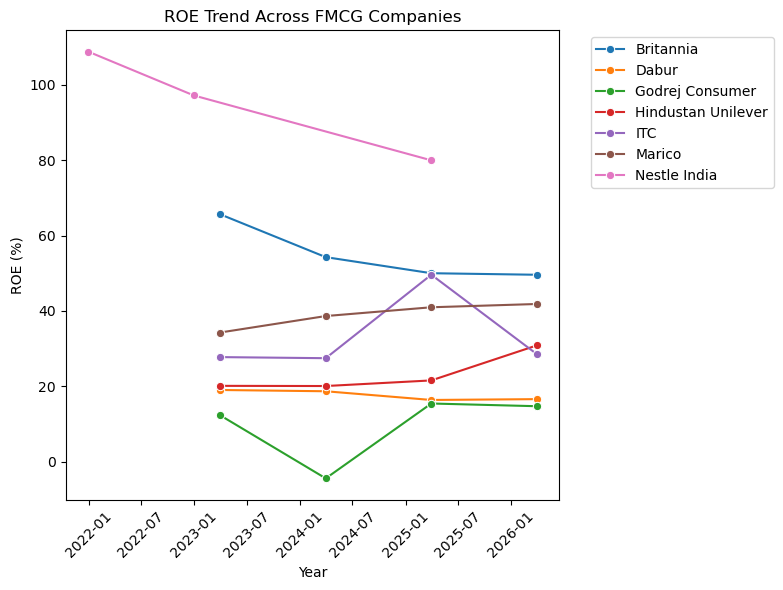

In [9]:
trend_df['Year'] = pd.to_datetime(trend_df['Year'])

plt.figure(figsize=(8,6))
sns.lineplot(data=trend_df, x='Year', y='ROE (%)', hue='Company', marker='o')
plt.title('ROE Trend Across FMCG Companies')
plt.ylabel('ROE (%)')
plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('fmcg_data/roe_trend.png')
plt.show()

#### Key Observations

### Latest Year ROE Comparison

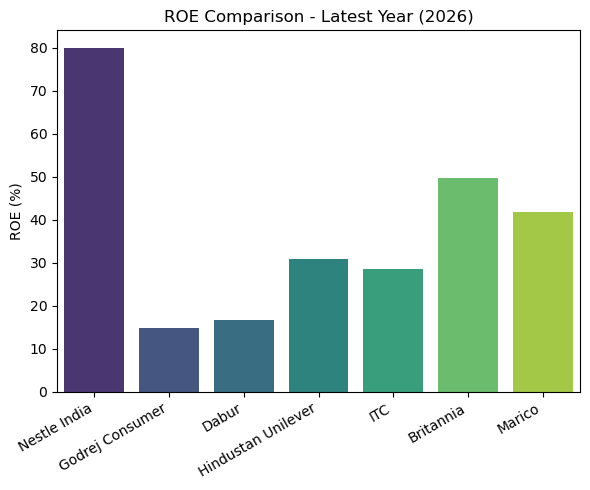

In [17]:
latest_year_data = trend_df.sort_values('Year').groupby('Company').tail(1)
plt.figure(figsize=(6,5))
sns.barplot(data=latest_year_data, x='Company', y='ROE (%)', hue='Company', palette='viridis', legend=False)
plt.title('ROE Comparison - Latest Year (2026)')
plt.ylabel('ROE (%)')
plt.xlabel('')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('fmcg_data/roe_comparison_latest.png')
plt.show()

#### Key Observations

### Debt to Equity Comparison

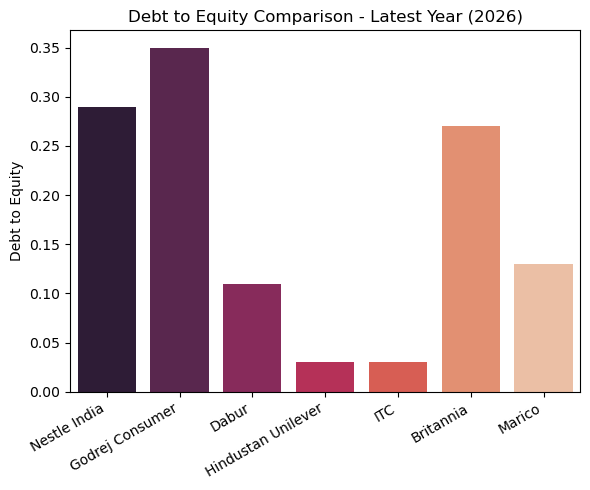

In [18]:
latest_year_data = trend_df.sort_values('Year').groupby('Company').tail(1)
plt.figure(figsize=(6,5))
sns.barplot(data=latest_year_data, x='Company', y='Debt to Equity',hue='Company', palette='rocket',legend=False)
plt.title('Debt to Equity Comparison - Latest Year (2026)')
plt.ylabel('Debt to Equity')
plt.xlabel('')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('fmcg_data/debt_equity_comparison.png')
plt.show()

#### Key Observations

### NOTE:- Nestle India's latest available data is from FY 2025 (fiscal year change), while other companies' latest data is from FY 2026. Comparisons use each company's most recent available year.